<img src=https://audiovisuales.icesi.edu.co/assets/custom/images/ICESI_logo_prin_descriptor_RGB_POSITIVO_0924.jpg width=200>

*Milton Orlando Sarria Paja, PhD.*

----

# **Optimizando la Conversión en E-commerce**

Vamos a entender cómo los conceptos teóricos abordados en el curso se integran para resolver un problema de negocio real de principio a fin, desde la predicción de un valor hasta la clasificación de un cliente y la selección del mejor modelo.

#### **Del Concepto al Código: Por Qué la Teoría es tu GPS**



* **¿Regresión Lineal o Logística?** La teoría te dice que depende de si tu objetivo es predecir un *valor* (cuánto interés tiene un cliente) o una *acción* (¿comprará o no?).
  
  
* **¿Por qué Regularización (L1/L2)?** La teoría nos advierte del *overfitting*. Con 17 características sobre el comportamiento de un usuario, ¿cómo te aseguras de que tu modelo no está simplemente memorizando sesiones pasadas en lugar de encontrar patrones reales?

  
* **¿Accuracy es suficiente?** La teoría de métricas nos obliga a preguntar: ¿Qué es más costoso para el negocio, ignorar a un comprador potencial (Falso Negativo) o hacerle una oferta a alguien que solo estaba mirando (Falso Positivo)?

  


---

## **El Problema: Reducir el Abandono de Carritos de Compra**

**Planteamiento del Caso:**
ShopSphere, un e-commerce en crecimiento, enfrenta un reto clave: aunque recibe un alto tráfico y los usuarios muestran interés en sus productos, las tasas de conversión siguen siendo bajas. Como consultor de Inteligencia Artificial, tu misión es **proponer y desarrollar una estrategia basada en Machine Learning** que permita identificar a los usuarios con mayor probabilidad de compra y activar intervenciones personalizadas en tiempo real (ej. descuentos selectivos), con el fin de **incrementar la conversión y maximizar el valor de cada visita**.


**El Dataset:** [Online Shoppers Purchasing Intention Dataset de UCI](https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset). Contiene métricas de sesión de más de 12,000 usuarios, incluyendo el tipo de páginas que visitaron, el día del mes, el tipo de visitante, y si la sesión terminó en una compra.

**Nuestra Misión se divide en dos partes:**
1.  **Mini-Desafío de Regresión:** Predecir el "valor de la sesión" para medir el interés del usuario.
2.  **Mini-Desafío de Clasificación:** Predecir si el usuario finalmente realizará una compra.


### **Manos a la Obra - El Flujo de Trabajo**

-----

### Análisis Exploratorio de Intención de Compra en E-commerce

**Objetivo:** Entender la estructura, distribuciones y relaciones presentes en el dataset para formular hipótesis sobre qué comportamientos de los usuarios influyen en la decisión de compra.

-----

#### **1. Configuración e Importación de Datos**

Primero, importamos las librerías necesarias y cargamos el dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Establecemos un estilo visual para los gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
df = pd.read_csv("online_shoppers_intention.csv")
df.head(3)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.0,0.0,0.1,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False


### **Variables numéricas:**

1. **Administrative**
   Número de páginas administrativas visitadas en la sesión (ej. páginas de cuenta, registro, inicio de sesión).

2. **Administrative Duration**
   Tiempo total (en segundos) que el usuario pasó en páginas administrativas.

3. **Informational**
   Número de páginas informativas visitadas (ej. páginas de ayuda, preguntas frecuentes).

4. **Informational Duration**
   Tiempo total en páginas informativas.

5. **Product Related**
   Número de páginas relacionadas con productos visitadas (ej. páginas de catálogos o fichas de producto).

6. **Product Related Duration**
   Tiempo total en páginas relacionadas con productos.

7. **Bounce Rate**
   Porcentaje de sesiones en las que el usuario entra a una página y abandona sin interactuar más (métrica de Google Analytics).

8. **Exit Rate**
   Porcentaje de veces que una página fue la última visitada de la sesión (métrica de Google Analytics).

9. **Page Value**
   Valor promedio de una página visitada antes de completar una transacción (según Google Analytics).

10. **Special Day**
    Indica qué tan cercana está la visita a una fecha especial (ej. Día de la Madre, San Valentín). Toma valores entre 0 y 1, donde 1 representa la máxima cercanía.

---

### **Variables categóricas:**

11. **OperatingSystems**
    Sistema operativo usado por el visitante (ej. Windows, MacOS, Linux).

12. **Browser**
    Navegador utilizado (ej. Chrome, Firefox, Safari).

13. **Region**
    Región geográfica desde la cual el visitante accedió al sitio.

14. **TrafficType**
    Fuente o tipo de tráfico (ej. directo, buscador, campaña).

15. **VisitorType**
    Tipo de visitante: *Returning Visitor* (recurrente) o *New Visitor* (nuevo).

16. **Weekend**
    Valor booleano que indica si la visita ocurrió en fin de semana.

17. **Month**
    Mes en el que ocurrió la visita (ej. Jan, Feb, Mar).

18. **Revenue** (variable objetivo / clase)
    Variable booleana que indica si la sesión terminó en compra (**True**) o no (**False**).


-----

#### **2. Inspección Inicial del Dataset**

El primer paso es siempre tener una idea general de cómo se ven nuestros datos.


In [4]:
print("\n--- Información General (Tipos de Datos y Nulos) ---")
df.info()

print("\n--- Estadísticas Descriptivas (Columnas Numéricas) ---")
print(df.describe())


--- Información General (Tipos de Datos y Nulos) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                

##### **Pregunta 1 🧠**

**Pregunta:** Al observar el resultado de `df.info()`, notamos que columnas como `Month` y `VisitorType` son de tipo `object`. ¿Por qué un modelo de machine learning como la Regresión Logística no podría usar estos datos directamente y qué paso de preprocesamiento es necesario?

**Respuesta:** Los modelos matemáticos requieren entradas numéricas. No pueden interpretar texto como "June" o "Returning\_Visitor". Por lo tanto, es necesario un paso de preprocesamiento llamado **codificación** (como One-Hot Encoding con `pd.get_dummies` o Label Encoding) para convertir estas categorías en números que el modelo pueda entender.


-----

#### **3. Análisis de la Variable Objetivo (`Revenue`)**

Nuestra variable objetivo es `Revenue`, que indica si la sesión terminó en una compra (`True`) o no (`False`).

Revenue se traduce como ingresos.
En contabilidad y negocios, significa el dinero total que una empresa recibe por la venta de bienes o servicios antes de restar gastos, impuestos u otros costos. Es distinto de la ganancia, que resulta después de deducir esos costos.


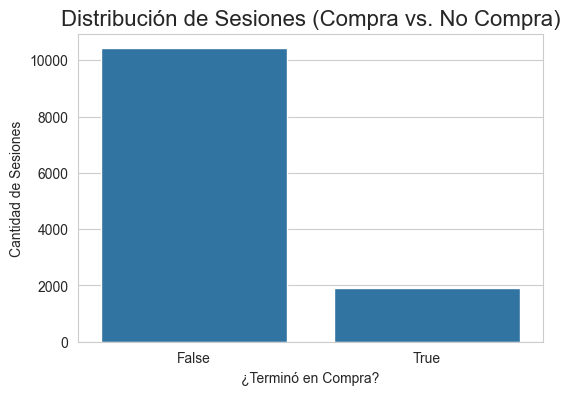

Porcentaje de sesiones sin compra (False): 84.53%
Porcentaje de sesiones con compra (True): 15.47%


In [5]:
# Visualizamos la distribución de la variable objetivo
plt.figure(figsize=(6, 4))
sns.countplot(x='Revenue', data=df)
plt.title('Distribución de Sesiones (Compra vs. No Compra)', fontsize=16)
plt.xlabel('¿Terminó en Compra?')
plt.ylabel('Cantidad de Sesiones')
plt.show()

# Calculamos el porcentaje exacto
revenue_counts = df['Revenue'].value_counts(normalize=True) * 100
print(f"Porcentaje de sesiones sin compra (False): {revenue_counts[False]:.2f}%")
print(f"Porcentaje de sesiones con compra (True): {revenue_counts[True]:.2f}%")



##### **Pregunta Conceptual 2 🧠**

**Pregunta:** El gráfico confirma que el dataset está **desbalanceado**. Si entrenáramos un modelo y obtuviéramos una **exactitud (accuracy) del 85%**, ¿deberíamos considerar que el modelo es bueno? ¿Por qué sí o por qué no?

**Respuesta:** No necesariamente. Un modelo **ingenuo** que siempre predijera `False` (sin compra) tendría una exactitud del 84.5%, ya que esa es la proporción de la clase mayoritaria. Por lo tanto, una exactitud del 85% es apenas mejor que adivinar siempre la opción más común. En datasets desbalanceados, la exactitud es una métrica engañosa y debemos usar otras como **Precision, Recall, F1-Score** o el **AUC-ROC**.



#### **4. Análisis de Variables Numéricas y Categóricas**

Ahora, exploremos las características para entender el comportamiento del usuario.


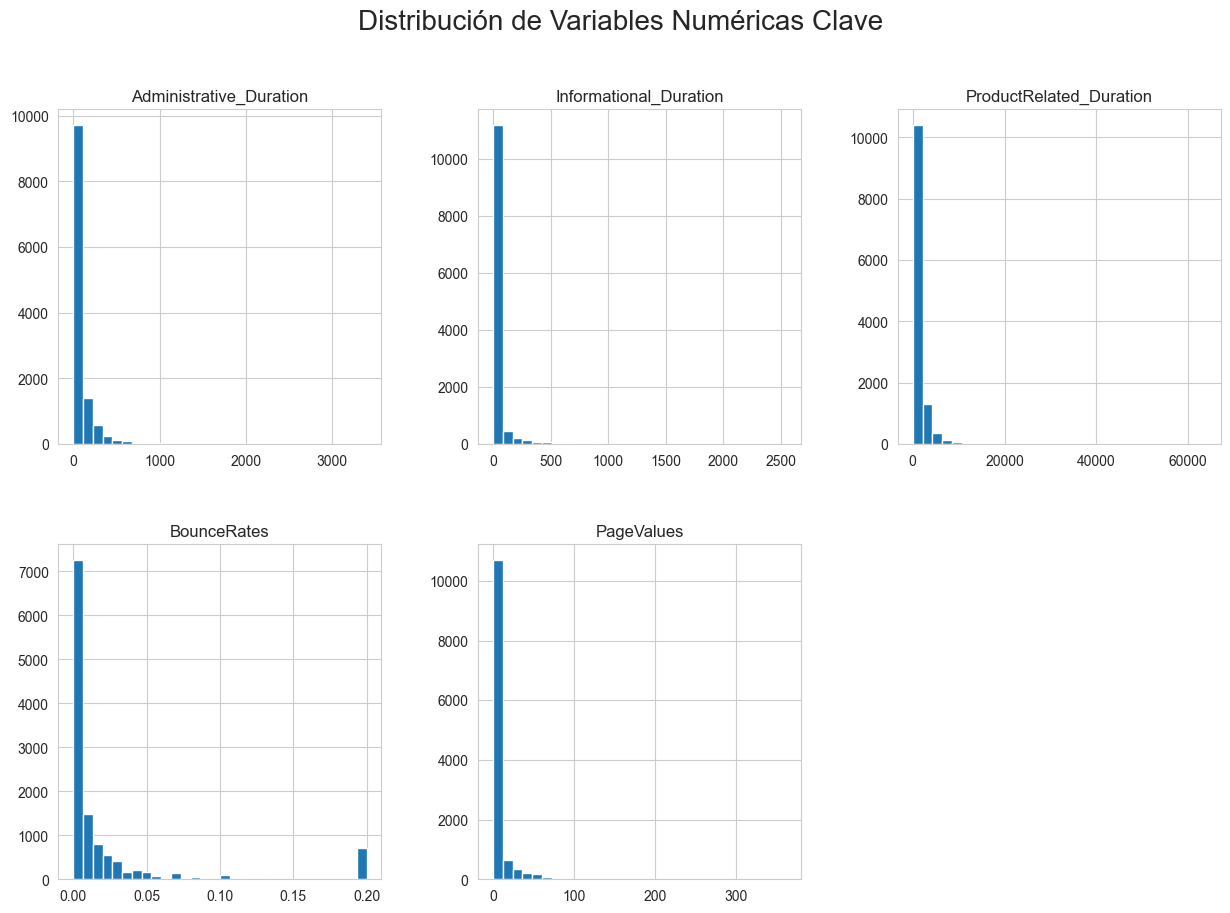

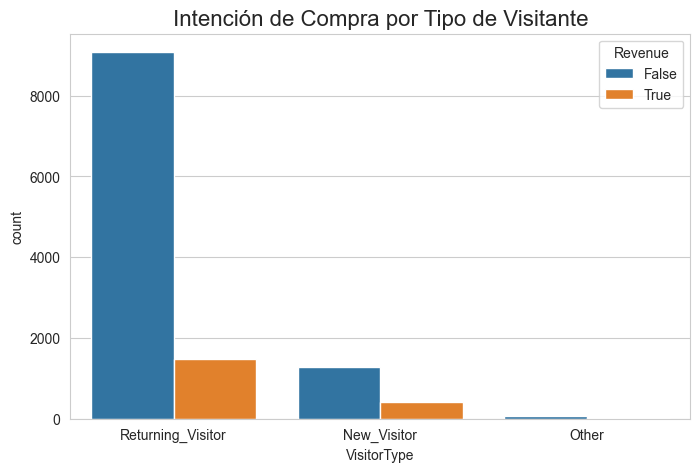

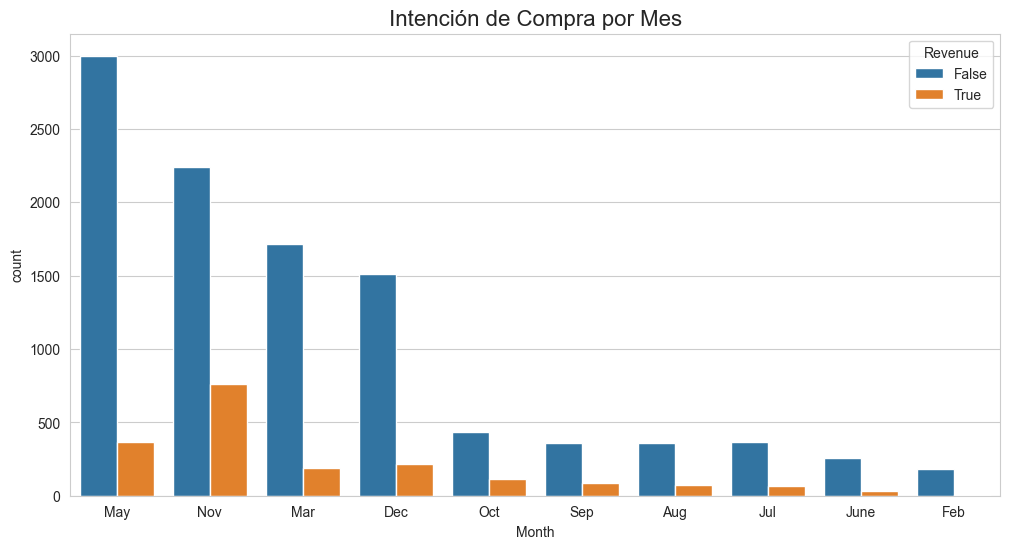

In [6]:
# Distribución de algunas variables numéricas clave
numerical_features = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'BounceRates', 'PageValues']
df[numerical_features].hist(bins=30, figsize=(15, 10), layout=(2, 3))
plt.suptitle('Distribución de Variables Numéricas Clave', fontsize=20)
plt.show()

# Relación del tipo de visitante con la compra
plt.figure(figsize=(8, 5))
sns.countplot(x='VisitorType', hue='Revenue', data=df)
plt.title('Intención de Compra por Tipo de Visitante', fontsize=16)
plt.show()

# Relación del mes con la compra
plt.figure(figsize=(12, 6))
sns.countplot(x='Month', hue='Revenue', data=df, order=df['Month'].value_counts().index)
plt.title('Intención de Compra por Mes', fontsize=16)
plt.show()

##### **Pregunta Conceptual 3 🧠**

**Pregunta:** La distribución de las variables de duración (ej. `ProductRelated_Duration`) está fuertemente **sesgada a la derecha**. ¿Qué nos dice esto sobre el comportamiento típico de la mayoría de los usuarios en el sitio web?

**Respuesta:** Un sesgo a la derecha significa que la gran mayoría de las sesiones son muy cortas. La mayoría de los usuarios pasan poco tiempo en las páginas de productos. Sin embargo, hay un pequeño número de usuarios (la "cola larga" de la distribución) que pasan una cantidad de tiempo extremadamente larga, lo que podría indicar un alto interés o un comportamiento atípico.

-----

#### **5. Análisis de Correlaciones y Relaciones Bivariadas**

Finalmente, busquemos relaciones entre las variables, especialmente con nuestra variable objetivo.


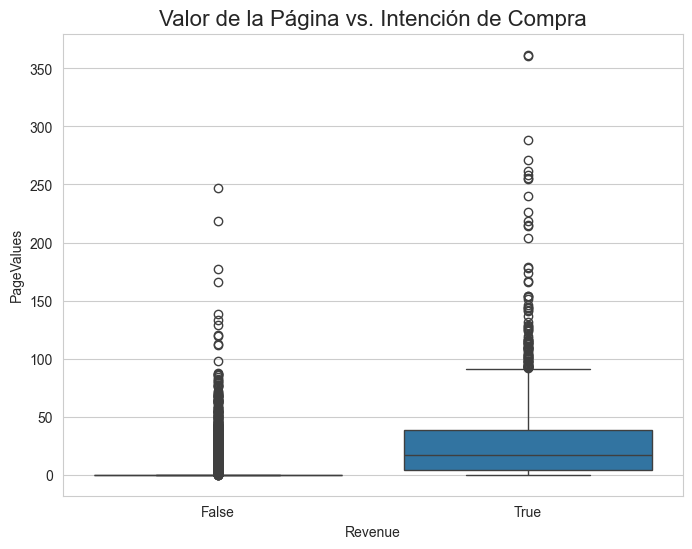

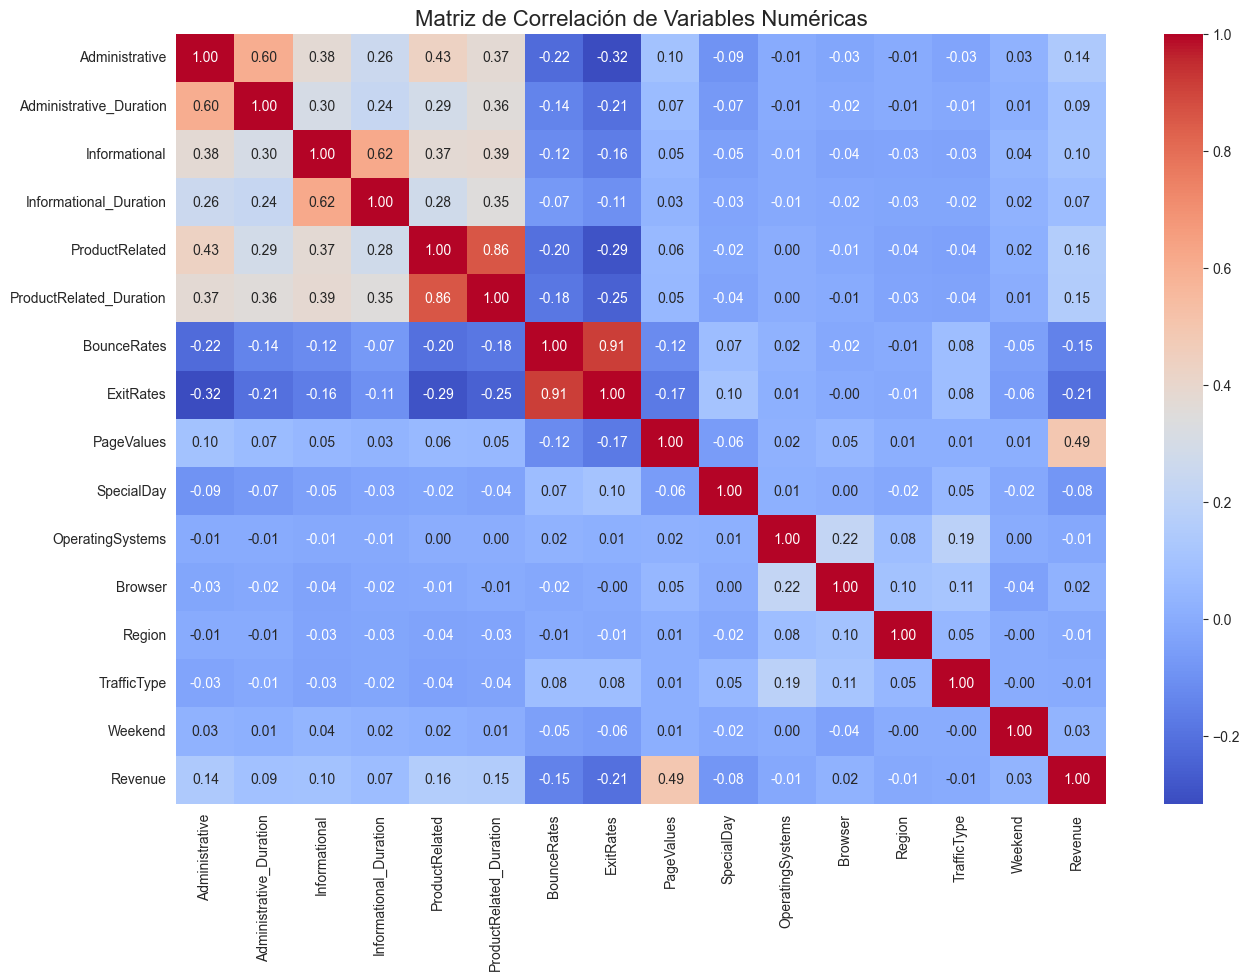

In [7]:
# Boxplot para ver la relación entre PageValues y Revenue
plt.figure(figsize=(8, 6))
sns.boxplot(x='Revenue', y='PageValues', data=df)
plt.title('Valor de la Página vs. Intención de Compra', fontsize=16)
plt.show()

# Matriz de correlación para las variables numéricas
plt.figure(figsize=(15, 10))
# Convertimos 'Revenue' y 'Weekend' a números (0/1) para incluirlos en la correlación
df_corr = df.copy()
df_corr['Revenue'] = df_corr['Revenue'].astype(int)
df_corr['Weekend'] = df_corr['Weekend'].astype(int)
# Excluimos las columnas de texto para el cálculo
numeric_cols = df_corr.select_dtypes(include=np.number).columns.tolist()
correlation_matrix = df_corr[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=16)
plt.show()

##### **Pregunta Conceptual 4 🧠**

**Pregunta:** El boxplot muestra una diferencia muy marcada en la distribución de `PageValues` para las sesiones que terminaron en compra frente a las que no. Además, la matriz de correlación muestra que `PageValues` es la variable con la correlación positiva más alta con `Revenue`. ¿Por qué esta variable es, intuitivamente, un predictor tan fuerte?


**Respuesta:** La variable `PageValues` representa el valor promedio de una página web, calculado por Google Analytics y basado en la contribución de esa página a las conversiones. Por definición, un valor alto indica que el usuario está navegando por páginas que históricamente llevan a una compra. Por lo tanto, es lógico y esperado que sea el predictor más fuerte de la intención de compra.


### **Mini-Desafío de Regresión - Prediciendo el Valor de la Sesión (`PageValues`)**

**Objetivo:** Construir y comparar varios modelos de regresión para predecir la métrica `PageValues`, utilizando preprocesamiento, validación cruzada y ajuste de hiperparámetros para seleccionar el mejor modelo.

#### **Configuración Inicial**

Importamos las librerías y cargamos el dataset que ya conocemos.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos y herramientas de Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [9]:
# Estilo visual para los gráficos
sns.set_style("whitegrid")
df = pd.read_csv("online_shoppers_intention.csv")
df.head(3)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.0,0.0,0.1,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False


#### **1. Preprocesamiento de Datos**

Antes de modelar, debemos preparar nuestros datos. Esto incluye la codificación de variables categóricas y el escalado de las numéricas.


In [10]:
# Definir características (X) y objetivo (y)
X = df.drop(['PageValues', 'Revenue'], axis=1) # Excluimos Revenue porque no se usa para predecir PageValues
y = df['PageValues']

# Dividir los datos ANTES de cualquier preprocesamiento para evitar fuga de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




In [11]:
X_train

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
1785,0,0.000000,0,0.0,7,95.000000,0.014286,0.061905,0.0,Mar,2,6,1,1,Returning_Visitor,False
10407,2,14.000000,0,0.0,81,1441.910588,0.002469,0.013933,0.0,Nov,2,2,3,2,Returning_Visitor,False
286,0,0.000000,0,0.0,1,0.000000,0.200000,0.200000,0.0,Mar,2,2,1,1,Returning_Visitor,False
6520,5,49.200000,4,379.0,5,74.600000,0.000000,0.018182,0.0,Sep,2,2,8,2,New_Visitor,False
12251,0,0.000000,1,5.0,9,279.000000,0.040000,0.041667,0.0,Nov,3,2,7,8,New_Visitor,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11964,14,1005.608333,0,0.0,25,732.344872,0.000000,0.015676,0.0,Nov,3,2,1,2,Returning_Visitor,False
5191,0,0.000000,0,0.0,14,340.000000,0.000000,0.015385,0.0,May,2,2,3,1,Returning_Visitor,True
5390,0,0.000000,0,0.0,3,189.000000,0.000000,0.066667,0.0,May,2,2,3,4,Returning_Visitor,False
860,0,0.000000,0,0.0,13,305.000000,0.000000,0.016667,0.0,Mar,1,1,1,2,New_Visitor,False



### **Tarea 1: Regresión Lineal Simple**

Usaremos solo `ProductRelated_Duration` para predecir `PageValues`.


--- Regresión Lineal Simple ---
Error Cuadrático Medio (MSE): 355.8623
Coeficiente de Determinación (R^2): 0.0040


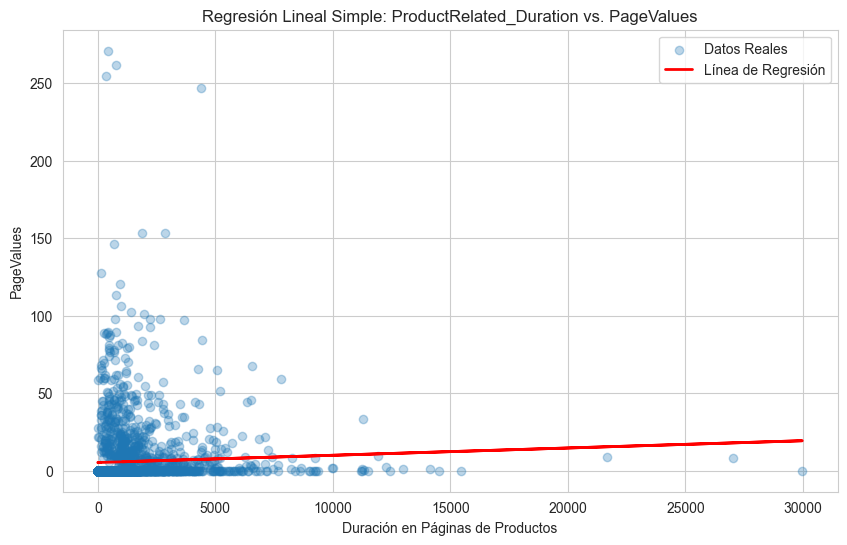

In [14]:
# Seleccionar solo la característica para el modelo simple
X_simple_train = X_train[['ProductRelated_Duration']]
X_simple_test = X_test[['ProductRelated_Duration']]
#normalizar

scaler=StandardScaler()
X_simple_train=scaler.fit_transform(X_simple_train)
X_simple_test=scaler.transform(X_simple_test)
# Entrenar el modelo
simple_lr = LinearRegression()
simple_lr.fit(X_simple_train, y_train)

# Predecir y evaluar
y_pred_simple = simple_lr.predict(X_simple_test)
mse_simple = mean_squared_error(y_test, y_pred_simple)
r2_simple = r2_score(y_test, y_pred_simple)

print(f"--- Regresión Lineal Simple ---")
print(f"Error Cuadrático Medio (MSE): {mse_simple:.4f}")
print(f"Coeficiente de Determinación (R^2): {r2_simple:.4f}")

# Visualización
plt.figure(figsize=(10, 6))
plt.scatter(X_simple_test, y_test, alpha=0.3, label='Datos Reales')
plt.plot(X_simple_test, y_pred_simple, color='red', linewidth=2, label='Línea de Regresión')
plt.title('Regresión Lineal Simple: ProductRelated_Duration vs. PageValues')
plt.xlabel('Duración en Páginas de Productos')
plt.ylabel('PageValues')
plt.legend()
plt.show()

**Conclusión Tarea 1:** El R² es bajo, lo que indica que `ProductRelated_Duration` por sí sola no es suficiente para explicar la variabilidad de `PageValues`.


### **Tarea 2: Regresión Lineal Múltiple y Modelos Avanzados**

Ahora usaremos todas las características relevantes y compararemos los modelos usando **validación cruzada** para una evaluación robusta.

#### **Modelo Base: Regresión Lineal Múltiple**

In [15]:
# Identificar columnas numéricas y categóricas
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

# Crear un transformador de preprocesamiento
# 1. Para numéricas: Estandarizar (escalar)
# 2. Para categóricas: Codificar con One-Hot Encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Creamos un pipeline que primero preprocesa los datos y luego aplica el modelo
pipeline_lr = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', LinearRegression())])

# Evaluamos usando validación cruzada de 5 folds
cv_scores_lr_mse = -cross_val_score(pipeline_lr, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
cv_scores_lr_r2 = cross_val_score(pipeline_lr, X_train, y_train, cv=5, scoring='r2')

print("--- Regresión Lineal Múltiple (Validación Cruzada) ---")
print(f"MSE promedio: {np.mean(cv_scores_lr_mse):.4f} (+/- {np.std(cv_scores_lr_mse):.4f})")
print(f"R^2 promedio: {np.mean(cv_scores_lr_r2):.4f} (+/- {np.std(cv_scores_lr_r2):.4f})")

--- Regresión Lineal Múltiple (Validación Cruzada) ---
MSE promedio: 324.1572 (+/- 59.5841)
R^2 promedio: 0.0505 (+/- 0.0046)


#### **Modelos Regularizados: Ridge (L2) y Lasso (L1) con Ajuste de Hiperparámetros**

Usaremos `GridSearchCV` para encontrar el mejor hiperparámetro `alpha` (λ).

In [16]:
# Pipeline para Ridge
pipeline_ridge = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('regressor', Ridge())])

# Pipeline para Lasso
pipeline_lasso = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('regressor', Lasso())])

# Definir el rango de alphas para probar
param_grid = {'regressor__alpha': np.logspace(-4, 2, 100)}

# GridSearch para Ridge
grid_search_ridge = GridSearchCV(pipeline_ridge, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_ridge.fit(X_train, y_train)

# GridSearch para Lasso
grid_search_lasso = GridSearchCV(pipeline_lasso, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_lasso.fit(X_train, y_train)

print(f"\n--- Ridge (L2) con GridSearchCV ---")
print(f"Mejor alpha: {grid_search_ridge.best_params_['regressor__alpha']:.4f}")
print(f"Mejor MSE (CV): {-grid_search_ridge.best_score_:.4f}")

print(f"\n--- Lasso (L1) con GridSearchCV ---")
print(f"Mejor alpha: {grid_search_lasso.best_params_['regressor__alpha']:.4f}")
print(f"Mejor MSE (CV): {-grid_search_lasso.best_score_:.4f}")


--- Ridge (L2) con GridSearchCV ---
Mejor alpha: 28.4804
Mejor MSE (CV): 324.0890

--- Lasso (L1) con GridSearchCV ---
Mejor alpha: 0.0050
Mejor MSE (CV): 324.1480



#### **Modelo No Lineal: KNN Regressor con Ajuste de Hiperparámetros**

El rendimiento de KNN depende de la escala de los datos (ya resuelto en el pipeline) y del número de vecinos (K).


In [17]:
# Pipeline para KNN
pipeline_knn = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', KNeighborsRegressor())])

# Definir el rango de K para probar
param_grid_knn = {'regressor__n_neighbors': np.arange(1, 31)}

# GridSearch para KNN
grid_search_knn = GridSearchCV(pipeline_knn, param_grid_knn, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_knn.fit(X_train, y_train)

print(f"\n--- KNN Regressor con GridSearchCV ---")
print(f"Mejor K (n_neighbors): {grid_search_knn.best_params_['regressor__n_neighbors']}")
print(f"Mejor MSE (CV): {-grid_search_knn.best_score_:.4f}")


--- KNN Regressor con GridSearchCV ---
Mejor K (n_neighbors): 29
Mejor MSE (CV): 326.3202


### **Tarea 3 (Bonus): Regresión Polinomial**

Investiguemos si una relación no lineal mejora el modelo.

In [18]:
# Creamos un pipeline que añade características polinomiales de grado 2 ANTES de la regresión
pipeline_poly = Pipeline(steps=[('preprocessor', preprocessor),
                                ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
                                ('regressor', LinearRegression())])

cv_scores_poly_mse = -cross_val_score(pipeline_poly, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

print(f"\n--- Regresión Polinomial (Grado 2) ---")
print(f"MSE promedio: {np.mean(cv_scores_poly_mse):.4f} (+/- {np.std(cv_scores_poly_mse):.4f})")


--- Regresión Polinomial (Grado 2) ---
MSE promedio: 714.1676 (+/- 793.0980)


In [26]:
cv_scores_poly_mse

array([ 276.03594238,  329.64310828,  402.16414972, 2297.40381601,
        265.59106055])

### **Punto de Conexión Teórico y Selección Final del Modelo**

#### **Interpretación de Coeficientes (Lasso)**

Una de las grandes ventajas de Lasso es que puede hacer selección de características. Veamos qué variables consideró importantes.


In [27]:
# Obtener los nombres de las características después del preprocesamiento
best_lasso_model = grid_search_lasso.best_estimator_
preprocessed_feature_names = best_lasso_model.named_steps['preprocessor'].get_feature_names_out()
lasso_coeffs = best_lasso_model.named_steps['regressor'].coef_

# Crear un DataFrame de coeficientes
coeffs_df = pd.DataFrame({'Característica': preprocessed_feature_names, 'Coeficiente': lasso_coeffs})
significant_coeffs = coeffs_df[coeffs_df['Coeficiente'] != 0].sort_values(by='Coeficiente', ascending=False)

print("\n--- Características más importantes según Lasso ---")
print(significant_coeffs)


--- Características más importantes según Lasso ---
                        Característica  Coeficiente
24              cat__VisitorType_Other     8.066577
6                     num__BounceRates     3.899217
10                        num__Browser     0.571678
19                      cat__Month_May     0.478077
0                  num__Administrative     0.373466
22                      cat__Month_Sep     0.313405
20                      cat__Month_Nov     0.307756
1         num__Administrative_Duration     0.269441
2                   num__Informational     0.208394
12                    num__TrafficType     0.169987
11                         num__Region     0.098766
3          num__Informational_Duration     0.098651
14                      cat__Month_Dec     0.070052
21                      cat__Month_Oct     0.034777
5         num__ProductRelated_Duration     0.034695
9                num__OperatingSystems    -0.155158
4                  num__ProductRelated    -0.316219
8          

In [ ]:
#ver todos los coeficientes!!
coeffs_df

**Análisis:** Los estudiantes deben observar que características como `ProductRelated`, `ExitRates` (negativo), y `BounceRates` (negativo) tienen los coeficientes más grandes, lo cual es lógico: pasar más tiempo en páginas de productos aumenta el valor de la sesión, mientras que tasas de rebote y salida altas lo disminuyen.

#### **Tabla Comparativa y Selección del Mejor Modelo**

In [28]:
# Recopilamos los mejores scores de MSE de cada modelo
results = {
    'Modelo': ['Regresión Lineal Simple', 'Regresión Lineal Múltiple', 'Ridge (L2)', 'Lasso (L1)', 'KNN', 'Regresión Polinomial'],
    'MSE Promedio (CV)': [
        mse_simple, # Usamos el del test set para comparación
        np.mean(cv_scores_lr_mse),
        -grid_search_ridge.best_score_,
        -grid_search_lasso.best_score_,
        -grid_search_knn.best_score_,
        np.mean(cv_scores_poly_mse)
    ]
}

results_df = pd.DataFrame(results).sort_values(by='MSE Promedio (CV)', ascending=True)

print("\n--- Tabla Comparativa de Modelos ---")
print(results_df)


--- Tabla Comparativa de Modelos ---
                      Modelo  MSE Promedio (CV)
2                 Ridge (L2)         324.088966
3                 Lasso (L1)         324.148013
1  Regresión Lineal Múltiple         324.157213
4                        KNN         326.320241
0    Regresión Lineal Simple         355.862299
5       Regresión Polinomial         714.167615



**Conclusión Final:**
Basado en la tabla de resultados, el **Ridge** es el ganador, ya que consistentemente presenta el menor Error Cuadrático Medio (MSE) en la validación cruzada. 

#### **Pregunta 1: Interpretación y Estrategia de Negocio**
"El modelo Lasso (L1) redujo varios coeficientes a cero, realizando una selección automática de características. Si fueras un consultor, ¿cómo le explicarías al equipo de marketing de 'ShopSphere' por qué un modelo **más simple** (con menos características) podría ser **más valioso** para el negocio que un modelo ligeramente más preciso pero mucho más complejo? ¿Qué riesgos de negocio se mitigan al usar el modelo de Lasso?"

**Respuesta Detallada:**
Un modelo más simple, como el que resulta de la regularización Lasso, es más valioso por tres razones clave:
1.  **Interpretabilidad y Accionabilidad:** Un modelo con menos variables es mucho más fácil de explicar. Podemos decirle al equipo de marketing: "Concéntrense en optimizar estas 5 variables, como el tiempo en páginas de productos y reducir la tasa de rebote, porque son las que realmente impulsan el valor de la sesión". Esta claridad permite tomar acciones de negocio directas y medibles, en lugar de enfrentarse a un modelo de "caja negra" con 20 variables interrelacionadas.
2.  **Robustez y Mantenimiento:** Los modelos complejos con muchas características son frágiles. Son susceptibles al sobreajuste y pueden fallar si cambia la distribución de una de las muchas variables de entrada. Un modelo simple es más robusto y menos propenso a dar predicciones erráticas con datos nuevos. Además, es mucho más fácil de mantener y actualizar en el futuro; se necesitan monitorear menos flujos de datos.
3.  **Mitigación de Riesgos:** El principal riesgo que se mitiga es el de **invertir recursos basados en "ruido"**. Un modelo complejo podría asignar importancia a una característica que solo por casualidad pareció relevante en los datos de entrenamiento. Al usar Lasso, nos enfocamos en las señales más fuertes y consistentes, reduciendo el riesgo de lanzar campañas de marketing costosas basadas en correlaciones espurias.

---

#### **Pregunta 2: El Dilema entre Complejidad y Rendimiento**
"Nuestro análisis mostró que la Regresión Polinomial tuvo el mejor rendimiento (MSE más bajo). Sin embargo, un modelo de regresión lineal múltiple con regularización Ridge fue casi tan bueno, pero es mucho más simple. En un escenario de producción real, ¿qué argumentos darías para **elegir el modelo Ridge (más simple)** en caso tal de que el Polinomial tuviese métricas ligeramente superiores? ¿En qué escenario sí justificarías la complejidad extra del modelo Polinomial?"

**Respuesta Detallada:**
Argumentaría a favor de implementar el **modelo Ridge (más simple)** en producción por las siguientes razones:
* **Coste Computacional:** El modelo polinomial genera una gran cantidad de características nuevas ($X^2$, $X_1 \cdot X_2$, etc.), lo que lo hace más lento para entrenar y, más importante, para generar predicciones en tiempo real. Si el modelo se usa para, por ejemplo, hacer una oferta a un cliente mientras navega, la velocidad es crítica.
* **Riesgo de Sobreajuste Extremo:** Aunque la validación cruzada nos da confianza, los modelos polinomiales tienen un riesgo inherente de sobreajuste a las particularidades del conjunto de entrenamiento. El modelo Ridge es, por diseño, más generalizable y menos propenso a este riesgo.
* **Interpretabilidad (Navaja de Ockham):** Si dos modelos ofrecen un rendimiento similar, siempre se debe preferir el más simple. Es más fácil de explicar, depurar y mantener.

Justificaría la complejidad extra del **modelo Polinomial** solo si esa pequeña mejora en el MSE se traduce en un **impacto económico significativo y demostrable**. Por ejemplo, si un análisis de coste-beneficio revela que reducir el error de predicción en ese pequeño porcentaje adicional permite identificar un segmento de clientes que genera millones de dólares en ventas adicionales, entonces y solo entonces, el aumento en el coste computacional y la complejidad estaría justificado.

#### **Pregunta 3: Cuestionando la Métrica de Evaluación**
"Utilizamos el Error Cuadrático Medio (MSE) para optimizar y comparar nuestros modelos. El MSE penaliza los errores grandes de forma cuadrática. Imagina dos escenarios de negocio para 'ShopSphere':
* **Escenario A:** Quieren identificar de forma general a los usuarios con "alto interés" para análisis de mercado.
* **Escenario B:** Quieren predecir el `PageValues` para decidir si ofrecer un cupón de **alto valor** a los usuarios que superen un umbral de predicción.

¿Es el MSE la métrica ideal para ambos escenarios? ¿Por qué sí o por qué no? ¿Qué métrica alternativa podrías proponer para el Escenario B y por qué?"

**Respuesta Detallada:**
No, el MSE no es ideal para ambos escenarios.
* **Para el Escenario A**, donde el objetivo es un análisis general, el **MSE (o RMSE)** es adecuado. Nos da una buena idea del error de predicción promedio y funciona bien para evaluar el rendimiento general del modelo.

* **Para el Escenario B**, el MSE es problemático. Al penalizar los errores grandes de forma cuadrática, el modelo se esforzará mucho en no cometer errores enormes en las predicciones de `PageValues` muy altos. Sin embargo, el coste de negocio de una **subestimación** (predecir un valor bajo para un cliente que en realidad era muy valioso, y por tanto no ofrecerle el cupón) es probablemente mucho mayor que el de una **sobreestimación** (ofrecer el cupón a alguien con un interés ligeramente menor).

* **Métrica Alternativa:** Para el Escenario B, una métrica mejor sería una **función de coste asimétrica personalizada** o, de forma más simple, el **Error Absoluto Medio (MAE)**. El **MAE** no eleva los errores al cuadrado, por lo que es menos sensible a los outliers y no se enfoca tan obsesivamente en los errores grandes. Aún mejor sería crear una métrica ponderada que penalice más la subestimación que la sobreestimación, alineando directamente el entrenamiento del modelo con el objetivo de negocio de no perder clientes de alto valor.

#### **Pregunta 4: Razonando sobre el Rendimiento de los Modelos**
"En nuestra comparación, el modelo KNN tuvo un rendimiento decente, pero fue superado por los modelos lineales (especialmente el Polinomial y Ridge). ¿Qué te dice esto sobre la **estructura fundamental de los datos**? ¿Qué característica de los datos hace que los modelos basados en ecuaciones (lineales/polinomiales) funcionen mejor que un modelo basado en instancia/distancia como KNN?"

**Respuesta Detallada:**
El hecho de que los modelos basados en ecuaciones (lineales y polinomiales) superaran a KNN sugiere que las relaciones en los datos, aunque no sean perfectamente lineales, siguen una **estructura global y bien definida**.
* Los modelos como Ridge y Lasso son buenos para encontrar el "hiperplano" óptimo que describe una tendencia general en todo el conjunto de datos. El éxito de la Regresión Polinomial refuerza esto, indicando que esta tendencia global no es una línea recta, sino una curva suave.
* KNN, por otro lado, es un modelo **local**. No asume ninguna estructura subyacente en los datos; simplemente hace predicciones basadas en la proximidad inmediata. Su rendimiento inferior sugiere que la mejor predicción para un punto no depende solo de sus vecinos más cercanos, sino de un patrón global que afecta a todos los datos.
* Además, este dataset tiene muchas características (~17, que se convierten en más después del one-hot encoding). KNN sufre de la **"maldición de la dimensionalidad"**: en espacios de muchas dimensiones, el concepto de "distancia" o "cercanía" pierde su significado, y a todos los puntos les parece estar igual de lejos entre sí. Los modelos de regresión manejan la alta dimensionalidad de forma más efectiva, especialmente cuando se combinan con regularización.

### **Mini-Desafío de Clasificación - ¿Este usuario comprará?**

**Objetivo:** Construir, evaluar y seleccionar un modelo de clasificación para predecir la variable `Revenue`, prestando especial atención al manejo del desbalance de clases y al uso de la regularización.

#### **0. Configuración y Preprocesamiento**

Continuamos desde el notebook anterior, cargando los datos y preparándolos para la clasificación.



In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos y herramientas de Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, 
                             roc_curve, roc_auc_score, precision_recall_curve)

# Estilo visual para los gráficos
sns.set_style("whitegrid")
df = pd.read_csv("online_shoppers_intention.csv")

# Convertir la variable objetivo a numérica (0/1)
df['Revenue'] = df['Revenue'].astype(int)

# Definir características (X) y objetivo (y)
X = df.drop('Revenue', axis=1)
y = df['Revenue']

# Dividir los datos en entrenamiento y prueba (80/20)
# Usamos stratify=y para mantener la proporción de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#### **Tarea 1: Modelo Base con Regresión Logística**

Entrenamos un modelo simple usando solo `PageValues` y `ProductRelated_Duration`.


In [23]:
# Seleccionar solo las dos características para el modelo base
features_base = ['PageValues', 'ProductRelated_Duration']
X_train_base = X_train[features_base]
X_test_base = X_test[features_base]

# Es importante escalar incluso para el modelo simple
scaler_base = StandardScaler()
X_train_base_scaled = scaler_base.fit_transform(X_train_base)
X_test_base_scaled = scaler_base.transform(X_test_base)

# Entrenar el modelo de regresión logística
model_base = LogisticRegression(random_state=42)
model_base.fit(X_train_base_scaled, y_train)


LogisticRegression(random_state=42)

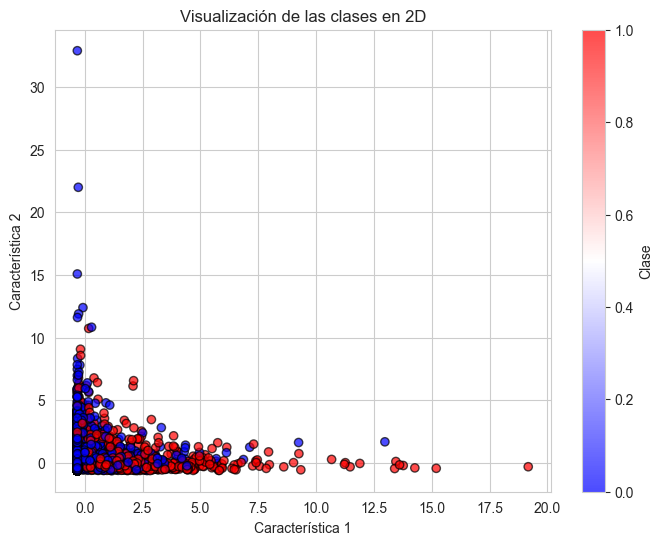

In [25]:
import matplotlib.pyplot as plt

# Supongamos que X_train tiene dos columnas
x1 = X_train_base_scaled[:, 0]
x2 = X_train_base_scaled[:, 1]

# Scatter plot con color según la clase en y_train
plt.figure(figsize=(8,6))
plt.scatter(x1, x2, c=y_train, cmap="bwr", alpha=0.7, edgecolors="k")

plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.title("Visualización de las clases en 2D")
plt.colorbar(label="Clase")
plt.show()


Text(0.5, 1.0, 'Frontera de decisión (Regresión Logística)')

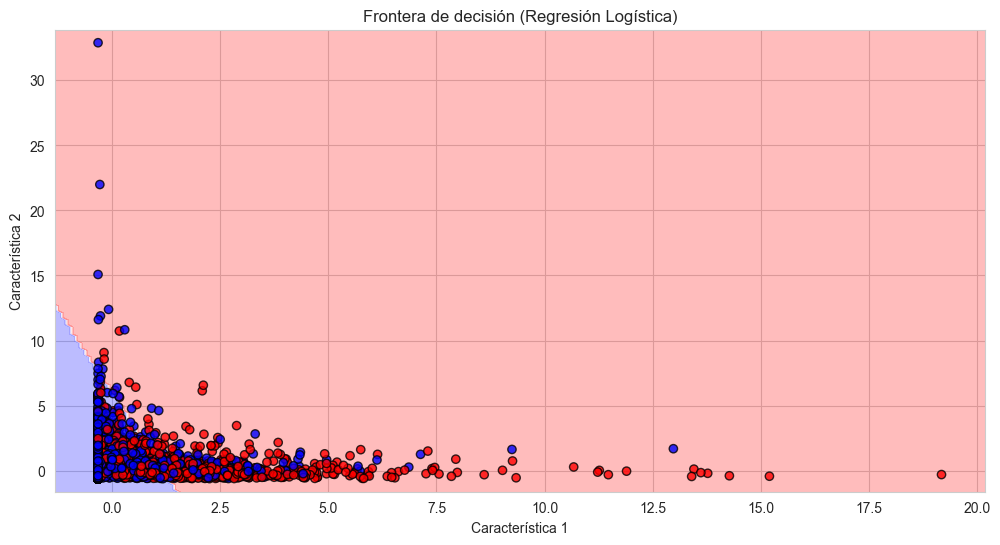

In [27]:
# Creamos una malla de puntos para cubrir el rango de X_train
x_min, x_max = X_train_base_scaled[:, 0].min() - 1, X_train_base_scaled[:, 0].max() + 1
y_min, y_max = X_train_base_scaled[:, 1].min() - 1, X_train_base_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
# Predecimos para cada punto de la malla
Z = model_base.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
# Dibujamos la frontera
plt.contourf(xx, yy, Z, alpha=0.3, cmap="bwr")
# Scatter plot de los datos originales
plt.scatter(x1, x2, c=y_train, cmap="bwr", edgecolors="k", alpha=0.8)
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.title("Frontera de decisión (Regresión Logística)")

#### **Tarea 2: Evaluación Crítica de Métricas**

Evaluamos el modelo base y analizamos sus resultados en el contexto del problema.


--- Evaluación del Modelo Base ---
Accuracy: 0.8800


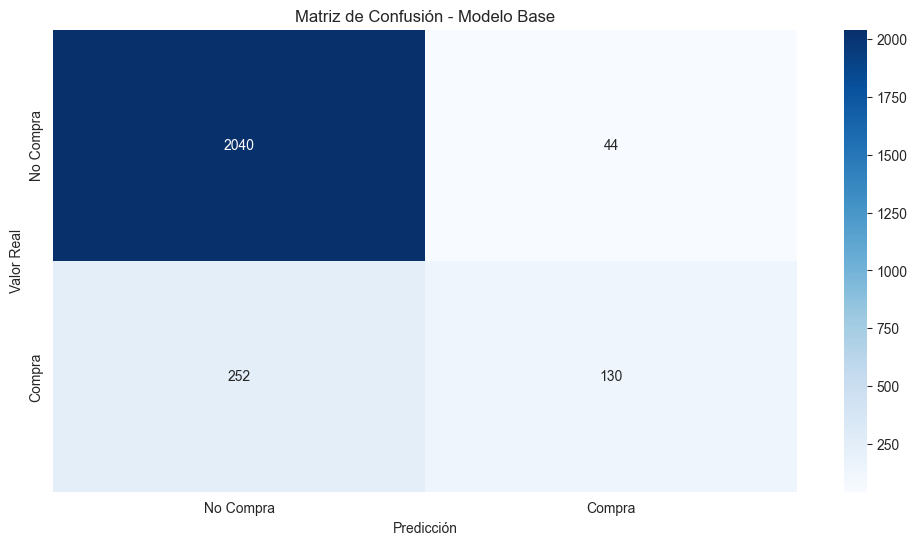


--- Reporte de Clasificación - Modelo Base ---
              precision    recall  f1-score   support

   No Compra       0.89      0.98      0.93      2084
      Compra       0.75      0.34      0.47       382

    accuracy                           0.88      2466
   macro avg       0.82      0.66      0.70      2466
weighted avg       0.87      0.88      0.86      2466



In [28]:
# Realizar predicciones
y_pred_base = model_base.predict(X_test_base_scaled)

# Calcular Accuracy
accuracy_base = accuracy_score(y_test, y_pred_base)
print(f"--- Evaluación del Modelo Base ---")
print(f"Accuracy: {accuracy_base:.4f}")

# Mostrar Matriz de Confusión
cm_base = confusion_matrix(y_test, y_pred_base)
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', xticklabels=['No Compra', 'Compra'], yticklabels=['No Compra', 'Compra'])
plt.title('Matriz de Confusión - Modelo Base')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()

# Mostrar reporte de clasificación completo
print("\n--- Reporte de Clasificación - Modelo Base ---")
print(classification_report(y_test, y_pred_base, target_names=['No Compra', 'Compra']))

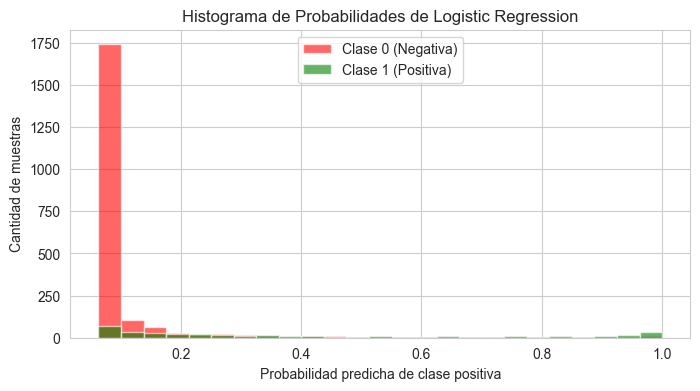

In [31]:
y_scores_lr = model_base.predict_proba(X_test_base_scaled)[:, 1]

plt.figure(figsize=(8, 4))

# Probabilidades para la clase 0
plt.hist(y_scores_lr[y_test == 0], bins=25, alpha=0.6, color='red', label='Clase 0 (Negativa)')

# Probabilidades para la clase 1
plt.hist(y_scores_lr[y_test == 1], bins=25, alpha=0.6, color='green', label='Clase 1 (Positiva)')

# Estética del gráfico
plt.title('Histograma de Probabilidades de Logistic Regression')
plt.xlabel('Probabilidad predicha de clase positiva')
plt.ylabel('Cantidad de muestras')
plt.legend(loc='upper center')
plt.grid(True)
plt.show()

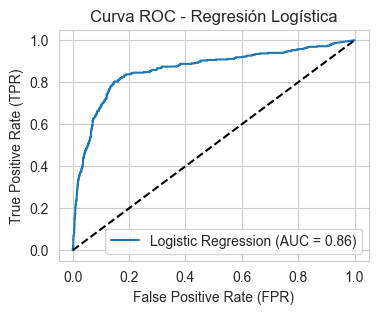

In [33]:
from sklearn.metrics import roc_curve, auc

# Calculamos FPR, TPR
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_scores_lr)

# Calculamos AUC
auc_lr = auc(fpr_lr, tpr_lr)

# Graficamos la curva ROC
plt.figure(figsize=(4, 3))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Línea aleatoria

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curva ROC - Regresión Logística')
plt.legend()
plt.grid(True)
plt.show()


##### **Pregunta Conceptual 1 🧠**

**Pregunta:** "Si 'ShopSphere' usa este modelo para ofrecer descuentos, un **Falso Positivo** cuesta dinero (un descuento innecesario a alguien que no iba a comprar). Un **Falso Negativo** es una venta perdida (no ofrecer un descuento a alguien que sí hubiera comprado con él). Viendo la matriz de confusión y el reporte, ¿qué métrica (Precision, Recall, F1-Score) crees que equilibra mejor estos dos costes para 'ShopSphere'?"
**Respuesta:**

  * El **F1-Score** es la media armónica de ambas y es ideal cuando los costes de ambos errores son comparables. Para un negocio, probablemente se quiera un buen equilibrio: no malgastar demasiado dinero pero tampoco perder demasiados clientes. Por lo tanto, el **F1-Score** es probablemente la métrica más completa para optimizar y seleccionar el modelo final, ya que busca un balance entre no ser ni demasiado derrochador (alta precisión) ni dejar pasar demasiadas oportunidades (alto recall).



#### **Tarea 3: Modelo Completo con Regularización**

Ahora usamos todas las características y aplicamos regularización para crear un modelo más robusto.


In [29]:
# Re-identificar columnas numéricas y categóricas del DataFrame completo
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

# Crear el ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# --- Modelo con Regularización L2 (Ridge) ---
pipeline_ridge = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('classifier', LogisticRegression(penalty='l2', solver='liblinear', random_state=42))])

# --- Modelo con Regularización L1 (Lasso) ---
pipeline_lasso = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('classifier', LogisticRegression(penalty='l1', solver='liblinear', random_state=42))])

# Definir el espacio de búsqueda del hiperparámetro C (inverso de lambda)
# Un valor pequeño de C significa una regularización más fuerte.
param_grid = {'classifier__C': np.logspace(-4, 4, 50)}

# Configurar GridSearchCV para encontrar el mejor modelo basado en F1-Score
grid_search_ridge = GridSearchCV(pipeline_ridge, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search_lasso = GridSearchCV(pipeline_lasso, param_grid, cv=5, scoring='f1', n_jobs=-1)

# Entrenar los modelos
print("Entrenando modelo Ridge (L2)...")
grid_search_ridge.fit(X_train, y_train)
print("Entrenando modelo Lasso (L1)...")
grid_search_lasso.fit(X_train, y_train)

print("\n--- Resultados de GridSearchCV ---")
print(f"Mejor F1-Score para Ridge (L2): {grid_search_ridge.best_score_:.4f} con C={grid_search_ridge.best_params_['classifier__C']:.4f}")
print(f"Mejor F1-Score para Lasso (L1): {grid_search_lasso.best_score_:.4f} con C={grid_search_lasso.best_params_['classifier__C']:.4f}")


Entrenando modelo Ridge (L2)...
Entrenando modelo Lasso (L1)...

--- Resultados de GridSearchCV ---
Mejor F1-Score para Ridge (L2): 0.5105 con C=3.7276
Mejor F1-Score para Lasso (L1): 0.5105 con C=5.4287



##### **Punto de conexión teórico: Interpretando Lasso**

Lasso puede hacer selección de características. Veamos qué variables consideró más importantes.


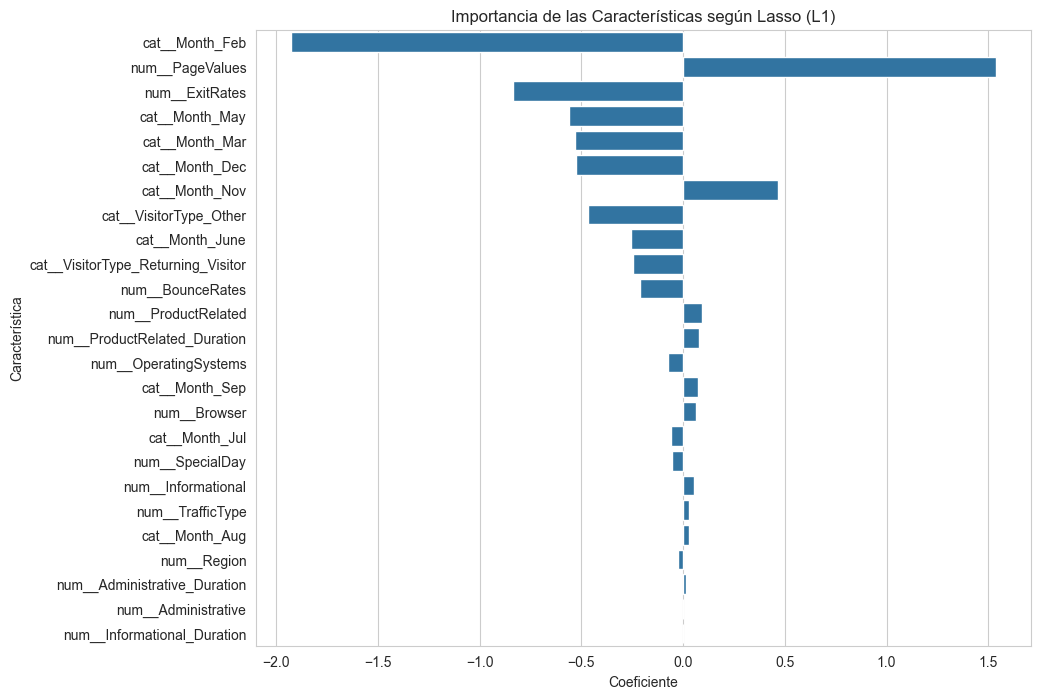

In [38]:
# Extraer los coeficientes del mejor modelo Lasso
best_lasso_model = grid_search_lasso.best_estimator_
lasso_coeffs = best_lasso_model.named_steps['classifier'].coef_[0]
feature_names = best_lasso_model.named_steps['preprocessor'].get_feature_names_out()

# Crear un DataFrame para visualizar la importancia
coeffs_df = pd.DataFrame({'Característica': feature_names, 'Coeficiente': lasso_coeffs})
significant_coeffs = coeffs_df[coeffs_df['Coeficiente'] != 0].sort_values('Coeficiente', key=abs, ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Coeficiente', y='Característica', data=significant_coeffs)
plt.title('Importancia de las Características según Lasso (L1)')
plt.show()

##### **Pregunta Conceptual 2 🧠**

**Pregunta:** Al observar los coeficientes de Lasso, vemos que algunas características tienen un coeficiente de cero. ¿Por qué es esto útil en un entorno de producción, más allá de la simple predicción?


**Respuesta:** Es útil por varias razones:

1.  **Reducción de Costes:** Si una característica es difícil o cara de obtener (ej. requiere una consulta a un sistema externo), y Lasso la elimina, la empresa puede dejar de recolectar ese dato, ahorrando tiempo y dinero.
2.  **Simplificación y Mantenimiento:** Un modelo con menos variables es más fácil de entender, explicar, depurar y mantener a lo largo del tiempo.
3.  **Enfoque de Negocio:** Permite al negocio centrarse en optimizar las variables que realmente mueven la aguja. Si `PageValues` y algunas variables asociadas a meses son importantes, el equipo de marketing puede enfocar sus esfuerzos en mejorar la calidad de las páginas y en las campañas de en determinados meses.


#### **Tarea 1: Validación Cruzada Final**

Elegimos el modelo Lasso como nuestro campeón (generalmente L1 es preferido por su capacidad de selección de características si el rendimiento es similar a L2) y realizamos una validación cruzada final para confirmar su rendimiento.


In [39]:
# Usamos el mejor estimador encontrado por GridSearchCV
champion_model = grid_search_lasso.best_estimator_

# Realizamos una validación cruzada de 5 folds sobre los datos de entrenamiento
cv_scores_f1 = cross_val_score(champion_model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
cv_scores_roc_auc = cross_val_score(champion_model, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)

print("\n--- Validación Cruzada Final del Modelo Campeón (Lasso) ---")
print(f"F1-Score promedio (CV): {np.mean(cv_scores_f1):.4f} (+/- {np.std(cv_scores_f1):.4f})")
print(f"ROC AUC promedio (CV): {np.mean(cv_scores_roc_auc):.4f} (+/- {np.std(cv_scores_roc_auc):.4f})")


--- Validación Cruzada Final del Modelo Campeón (Lasso) ---
F1-Score promedio (CV): 0.5105 (+/- 0.0260)
ROC AUC promedio (CV): 0.8974 (+/- 0.0107)


##### **Pregunta Conceptual 3 🧠**

**Pregunta:** "¿Por qué la puntuación media de la validación cruzada es una estimación más **honesta** del rendimiento del modelo en datos futuros que la que obtuvimos en una sola división de `train_test_split` al principio?"


**Respuesta:** Una sola división `train_test_split` puede ser víctima de la suerte. Podríamos haber obtenido una división "fácil" donde el conjunto de prueba es muy similar al de entrenamiento, dándonos una visión demasiado optimista del rendimiento. O una división "difícil" que nos dé una visión pesimista. La **validación cruzada (K-Fold)** mitiga esto al entrenar y evaluar el modelo K veces en K subconjuntos diferentes de los datos, y luego promediar los resultados. Este promedio es una estimación mucho más robusta y fiable de cómo se comportará el modelo en datos nuevos y no vistos, ya que reduce la varianza asociada a una única división.

#### **Tarea 2: Recomendación Final**

Evaluamos el modelo campeón en el conjunto de prueba (`X_test`) que hemos mantenido separado durante todo el proceso.


--- Evaluación Final en el Conjunto de Prueba ---
              precision    recall  f1-score   support

   No Compra       0.89      0.98      0.93      2084
      Compra       0.74      0.36      0.48       382

    accuracy                           0.88      2466
   macro avg       0.82      0.67      0.71      2466
weighted avg       0.87      0.88      0.86      2466



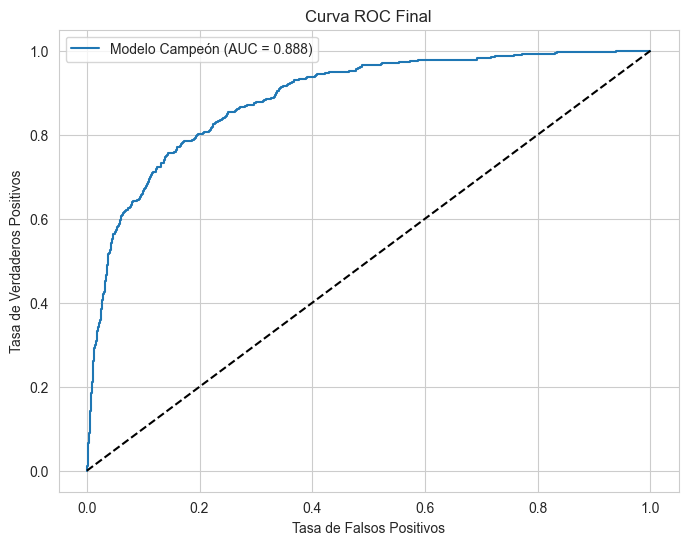

In [40]:
# Realizar predicciones finales en el conjunto de prueba
y_pred_final = champion_model.predict(X_test)
y_pred_proba_final = champion_model.predict_proba(X_test)[:, 1]

print("\n--- Evaluación Final en el Conjunto de Prueba ---")
print(classification_report(y_test, y_pred_final, target_names=['No Compra', 'Compra']))

# Curva ROC Final
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_final)
auc_final = roc_auc_score(y_test, y_pred_proba_final)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Modelo Campeón (AUC = {auc_final:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Curva ROC Final')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend()
plt.show()


##### **Recomendación para "ShopSphere"**

"Basado en el análisis, recomendamos implementar el **modelo de Regresión Logística con regularización Lasso (L1)**. Este modelo no solo logra un buen equilibrio entre la identificación de compradores potenciales (Recall) y la minimización de ofertas innecesarias (Precision), sino que también simplifica el problema al identificar las características más influyentes del comportamiento del usuario, como `PageValues` y la actividad en los meses en diferentes momentos del año.

Sugerimos usar las predicciones de este modelo para dirigir una campaña de descuentos en tiempo real a los usuarios cuya probabilidad de compra supere un umbral predefinido, optimizando así la inversión en marketing y maximizando la tasa de conversión."